# Communities and Crime — evaluacija i poređenje

Ova sveska:
1. Učitava sve rezultate klasterovanja
2. Pravi sveobuhvatnu tabelu poređenja metrika
3. Vizuelizuje poređenje metrika po algoritmima i skupovima karakteristika
4. Interpretira klastere — kakve zajednice su završile u kojoj grupi?

> **Napomena:** prvo pokrenuti sveske **`01`** i **`02`**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import joblib
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


## 1. Učitavanje podataka i rezultata klasterovanja

In [2]:
X_full    = pd.read_csv('../data/data_preprocessed.csv')
X_imputed = pd.read_csv('../data/data_imputed.csv')
X_pca70   = pd.read_csv('../data/data_pca_70.csv')
X_pca80   = pd.read_csv('../data/data_pca_80.csv')
X_econ    = pd.read_csv('../data/data_economic.csv')
targets   = pd.read_csv('../data/data_targets.csv')

kmeans_results  = joblib.load('../results/results_kmeans.pkl')
agg_results     = joblib.load('../results/results_agglomerative.pkl')
dbscan_results  = joblib.load('../results/results_dbscan.pkl')
clarans_results = joblib.load('../results/results_clarans.pkl')
birch_results   = joblib.load('../results/results_birch.pkl')
cure_results    = joblib.load('../results/results_cure.pkl')

pca_viz = PCA(n_components=2, random_state=42)
X_viz = pca_viz.fit_transform(X_full)

results_df = pd.read_csv('../results/clustering_results.csv')
print(f'Loaded {len(results_df)} algorithm-feature configurations.')
results_df.head()

Loaded 29 algorithm-feature configurations.


,Algorithm,Feature Set,n_clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,Full,3,0.1777,1.7846,370.6
1,K-Means,PCA-70,3,0.2686,1.3279,606.3
2,K-Means,PCA-80,3,0.2277,1.5045,502.4
3,K-Means,Economic,3,0.2065,1.6030,720.4
4,Agglomerative (Ward),Full,3,0.1604,1.8891,324.6


## 2. Tabelarni prikaz poređenja metrika

- **Silueta koeficijent** [-1, 1]: što je veći, to je bolje. Meri koliko je tačka slična svom klasteru u poređenju sa ostalima.
- **Davies-Bouldinov indeks** [0, ∞): što je manji, to je bolje. Meri prosečnu sličnost svakog klastera sa njemu najsličnijim klasterom.
- **Calinski-Harabasz indeks** [0, ∞): što je veći, to je bolje. Predstavlja odnos disperzije između klastera i disperzije unutar klastera.

In [3]:
print('=== All Configurations — Sorted by Silhouette Score ===')
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
results_df.sort_values('Silhouette', ascending=False)

=== All Configurations — Sorted by Silhouette Score ===


,Algorithm,Feature Set,n_clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
13,Agglomerative (Average),PCA-70,3,0.7693,0.2680,106.1000
9,Agglomerative (Complete),PCA-70,3,0.7693,0.2680,106.1000
14,Agglomerative (Average),PCA-80,3,0.7504,0.2869,93.0000
27,CURE,PCA-80,3,0.7504,0.2869,93.0000
10,Agglomerative (Complete),PCA-80,3,0.7504,0.2869,93.0000
8,Agglomerative (Complete),Full,3,0.7278,0.3817,75.1000
15,Agglomerative (Average),Economic,3,0.6796,0.3130,47.9000
28,CURE,Economic,3,0.6796,0.3130,47.9000
26,CURE,PCA-70,3,0.6561,0.4540,110.1000
12,Agglomerative (Average),Full,3,0.6112,0.5541,78.2000


In [4]:
print('=== Top 5 by Silhouette ===')
top5_sil = results_df.dropna(subset=['Silhouette']).sort_values('Silhouette', ascending=False).head(5)
print(top5_sil[['Algorithm', 'Feature Set', 'n_clusters', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']].to_string(index=False))

print('\n=== Top 5 by Davies-Bouldin ===')
top5_db = results_df.dropna(subset=['Davies-Bouldin']).sort_values('Davies-Bouldin').head(5)
print(top5_db[['Algorithm', 'Feature Set', 'n_clusters', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']].to_string(index=False))

print('\n=== Top 5 by Calinski-Harabasz ===')
top5_ch = results_df.dropna(subset=['Calinski-Harabasz']).sort_values('Calinski-Harabasz', ascending=False).head(5)
print(top5_ch[['Algorithm', 'Feature Set', 'n_clusters', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']].to_string(index=False))

=== Top 5 by Silhouette ===
               Algorithm Feature Set  n_clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz
 Agglomerative (Average)      PCA-70           3      0.7693          0.2680           106.1000
Agglomerative (Complete)      PCA-70           3      0.7693          0.2680           106.1000
 Agglomerative (Average)      PCA-80           3      0.7504          0.2869            93.0000
                    CURE      PCA-80           3      0.7504          0.2869            93.0000
Agglomerative (Complete)      PCA-80           3      0.7504          0.2869            93.0000

=== Top 5 by Davies-Bouldin ===
               Algorithm Feature Set  n_clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz
 Agglomerative (Average)      PCA-70           3      0.7693          0.2680           106.1000
Agglomerative (Complete)      PCA-70           3      0.7693          0.2680           106.1000
 Agglomerative (Average)      PCA-80           3      0.7504          0.286

## 3. Vizuelizacija poređenja rezultata

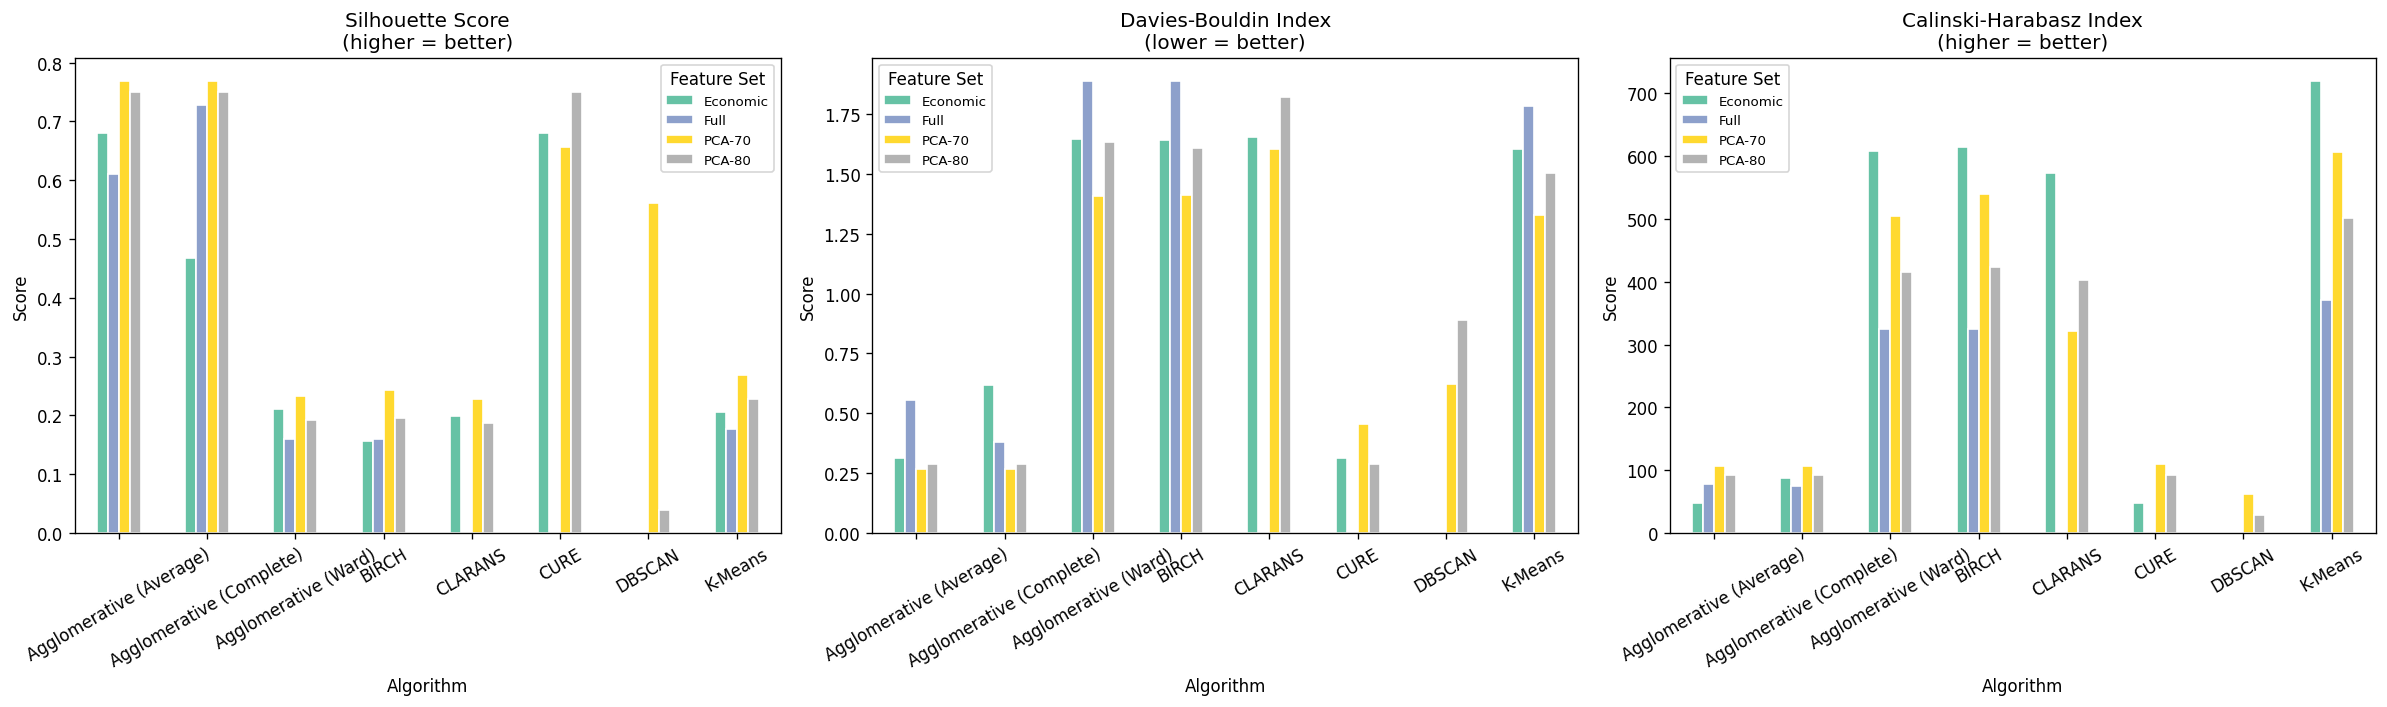

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

pivot_sil = results_df.pivot_table(values='Silhouette', index='Algorithm', columns='Feature Set')
pivot_sil.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Silhouette Score\n(higher = better)', fontsize=12)
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=8, title='Feature Set')
axes[0].tick_params(axis='x', rotation=30)

pivot_db = results_df.pivot_table(values='Davies-Bouldin', index='Algorithm', columns='Feature Set')
pivot_db.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Davies-Bouldin Index\n(lower = better)', fontsize=12)
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8, title='Feature Set')
axes[1].tick_params(axis='x', rotation=30)

pivot_ch = results_df.pivot_table(values='Calinski-Harabasz', index='Algorithm', columns='Feature Set')
pivot_ch.plot(kind='bar', ax=axes[2], colormap='Set2', edgecolor='white')
axes[2].set_title('Calinski-Harabasz Index\n(higher = better)', fontsize=12)
axes[2].set_ylabel('Score')
axes[2].legend(fontsize=8, title='Feature Set')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../figures/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

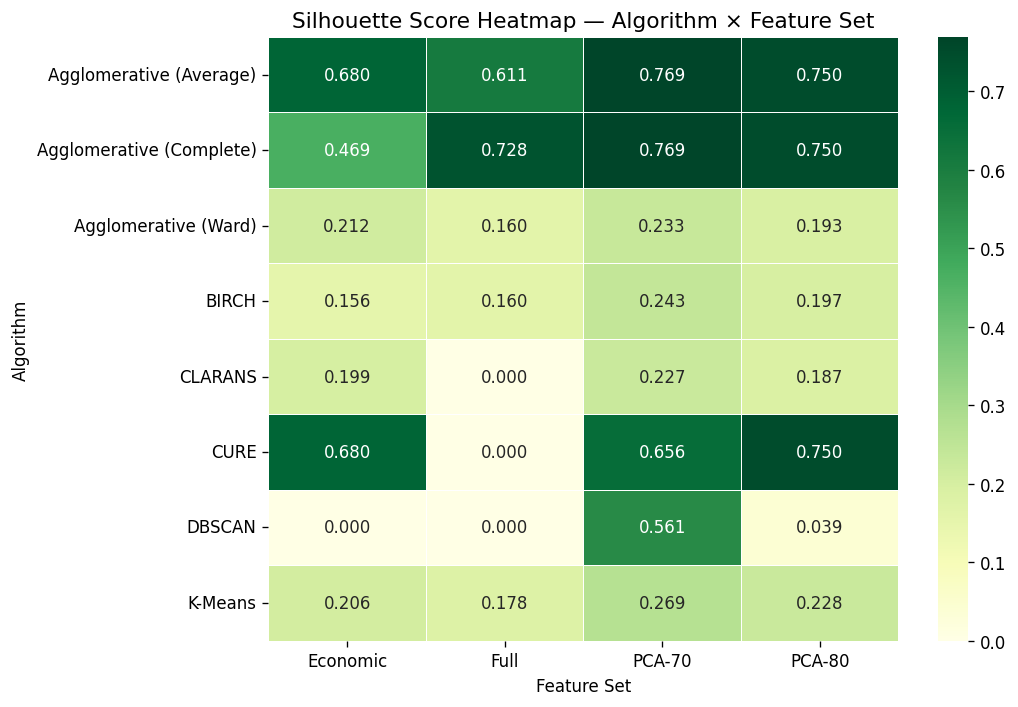

In [6]:
plt.figure(figsize=(9, 6))
sns.heatmap(
    pivot_sil.fillna(0), annot=True, fmt='.3f', cmap='YlGn',
    linewidths=0.5, annot_kws={'size': 10}
)
plt.title('Silhouette Score Heatmap — Algorithm × Feature Set', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/silhouette_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Najbolji algoritam — vizuelizacija klastera

In [7]:
best_row = results_df.dropna(subset=['Silhouette']).sort_values('Silhouette', ascending=False).iloc[0]
print(f'Best algorithm: {best_row["Algorithm"]}')
print(f'Feature set:    {best_row["Feature Set"]}')
print(f'Silhouette:     {best_row["Silhouette"]:.4f}')
print(f'Davies-Bouldin: {best_row["Davies-Bouldin"]:.4f}')
print(f'n_clusters:     {int(best_row["n_clusters"])}')

Best algorithm: Agglomerative (Average)
Feature set:    PCA-70
Silhouette:     0.7693
Davies-Bouldin: 0.2680
n_clusters:     3


In [15]:
algo = best_row['Algorithm']
fs   = best_row['Feature Set']

if algo == 'K-Means':
    best_labels = kmeans_results[fs]['labels']
elif algo == 'Agglomerative (Ward)':
    best_labels = agg_results[f'ward_{fs}']['labels']
elif algo == 'Agglomerative (Complete)':
    best_labels = agg_results[f'complete_{fs}']['labels']
elif algo == 'Agglomerative (Average)':
    best_labels = agg_results[f'average_{fs}']['labels']
elif algo == 'CLARANS':
    best_labels = clarans_results[fs]['labels']
elif algo == 'BIRCH':
    best_labels = birch_results[fs]['labels']
elif algo == 'DBSCAN':
    key = f'best_{fs}'
    best_labels = dbscan_results.get(key, dbscan_results[list(dbscan_results.keys())[-1]])['labels']
elif algo == 'CURE':
    best_labels = cure_results[fs]['labels']
else:
    best_labels = kmeans_results['Full']['labels']

print(f'Labels shape: {best_labels.shape}')
print(f'Unique clusters: {sorted(set(best_labels))}')

Labels shape: (2215,)
Unique clusters: [np.int64(0), np.int64(1), np.int64(2)]


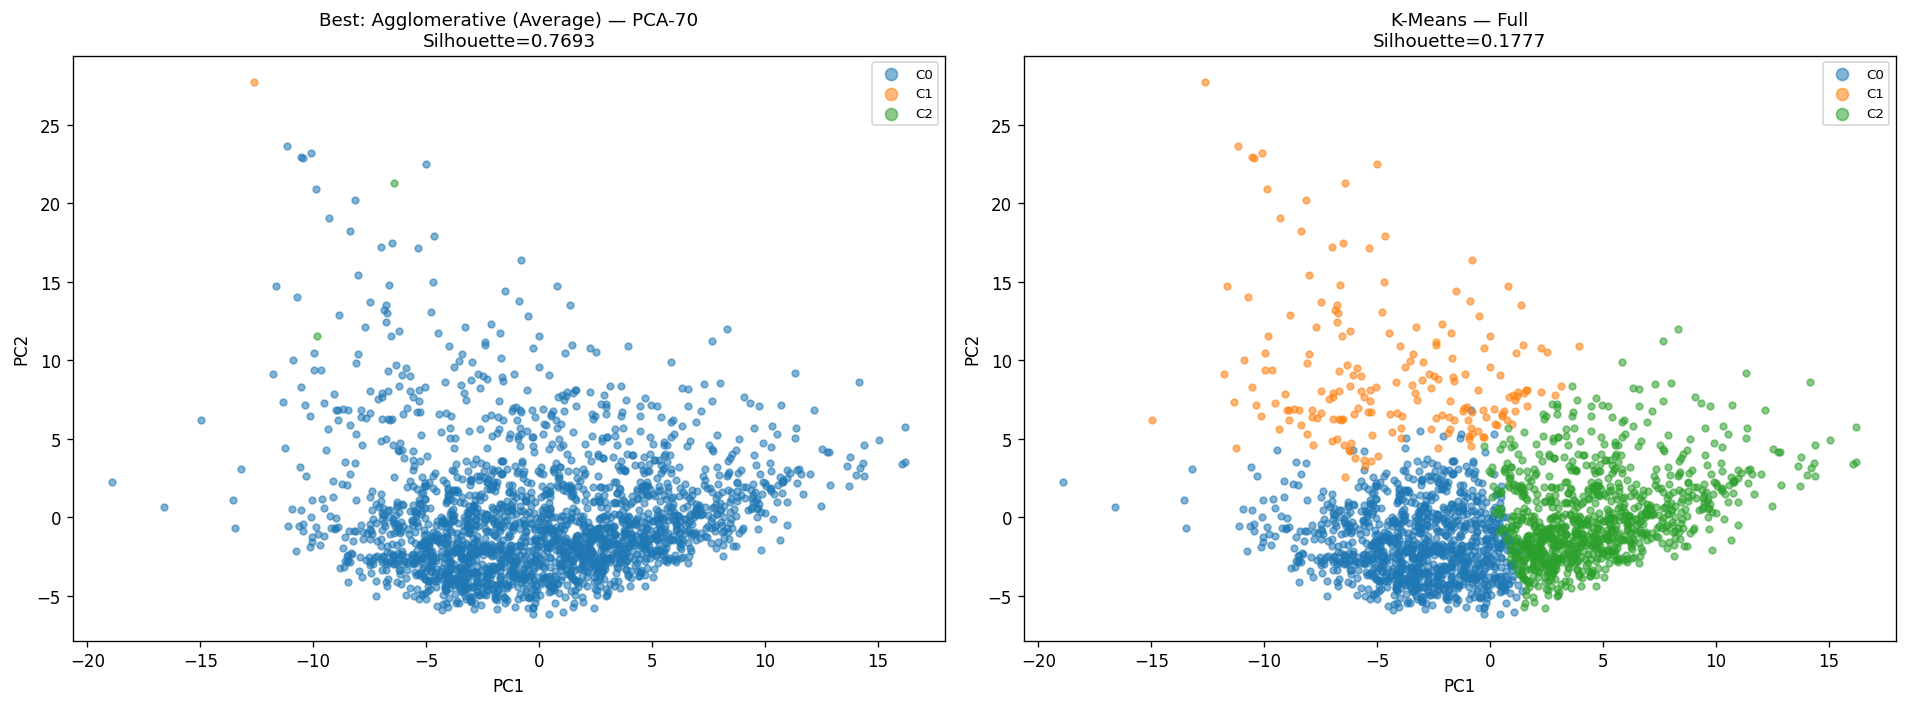

In [16]:
km_full_labels = kmeans_results['Full']['labels']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

unique = sorted(set(best_labels))
palette = sns.color_palette('tab10', n_colors=max(len(unique), 1))
for i, lbl in enumerate(unique):
    mask = best_labels == lbl
    c = 'lightgray' if lbl == -1 else palette[i % len(palette)]
    axes[0].scatter(X_viz[mask, 0], X_viz[mask, 1], c=[c], label=f'C{lbl}' if lbl != -1 else 'Noise', alpha=0.55, s=16)
axes[0].set_title(f'Best: {algo} — {fs}\nSilhouette={best_row["Silhouette"]:.4f}', fontsize=11)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8, markerscale=1.8)

unique2 = sorted(set(km_full_labels))
for i, lbl in enumerate(unique2):
    mask = km_full_labels == lbl
    c = palette[i % len(palette)]
    axes[1].scatter(X_viz[mask, 0], X_viz[mask, 1], c=[c], label=f'C{lbl}', alpha=0.55, s=16)
km_sil = results_df[(results_df['Algorithm']=='K-Means') & (results_df['Feature Set']=='Full')]['Silhouette'].values[0]
axes[1].set_title(f'K-Means — Full\nSilhouette={km_sil:.4f}', fontsize=11)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=8, markerscale=1.8)

plt.tight_layout()
plt.savefig('../figures/best_vs_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Interpretacija klastera

Za interpretaciju klastera koristimo K-Means na svim karakteristikama. Razlog za to je što ovaj pristup ima dve ključne prednosti za interpretaciju:
- **Svaka instanca je dodeljena klasteru** — nema šuma, kompletno pokrivanje svih 2215 instanci
- **Koriste se sve karakteristike** — sve 102 socioekonomske promenljive su uzete u obzir, 
  što daje potpuniju sliku profila klastera
  
U opisivanju klastera učestvuju:
- Medijana stopa kriminala (iz ciljnih promenljivih)
- Medijana socioekonomskih indikatora

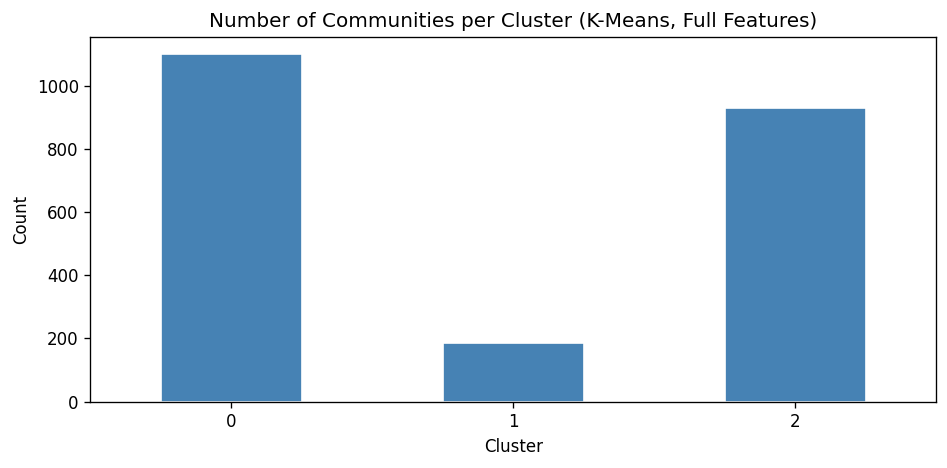

  Cluster 0: 1099 communities (49.6%)
  Cluster 1: 187 communities (8.4%)
  Cluster 2: 929 communities (41.9%)


In [17]:
interp_labels = km_full_labels
X_interp = X_imputed.copy()
X_interp['cluster'] = interp_labels
targets_cl = targets.copy()
targets_cl['cluster'] = interp_labels

cluster_sizes = pd.Series(interp_labels).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
cluster_sizes.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Number of Communities per Cluster (K-Means, Full Features)')
ax.set_xlabel('Cluster'); ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

for c, sz in cluster_sizes.items():
    print(f'  Cluster {c}: {sz} communities ({sz/len(interp_labels)*100:.1f}%)')

Median crime rates per cluster:
         violentPerPop  nonViolPerPop  murdPerPop  robbbPerPop  burglPerPop  \
cluster                                                                       
0             549.2200      5558.0000      5.2400     113.8900    1093.0400   
1             950.5100      5690.7400     10.6100     317.1400    1391.2400   
2             190.8400      3048.4200      0.0000      39.5000     548.1000   

         larcPerPop  autoTheftPerPop  
cluster                               
0         3936.8000         318.3300  
1         3223.2200        1049.0600  
2         2154.8800         225.2400  


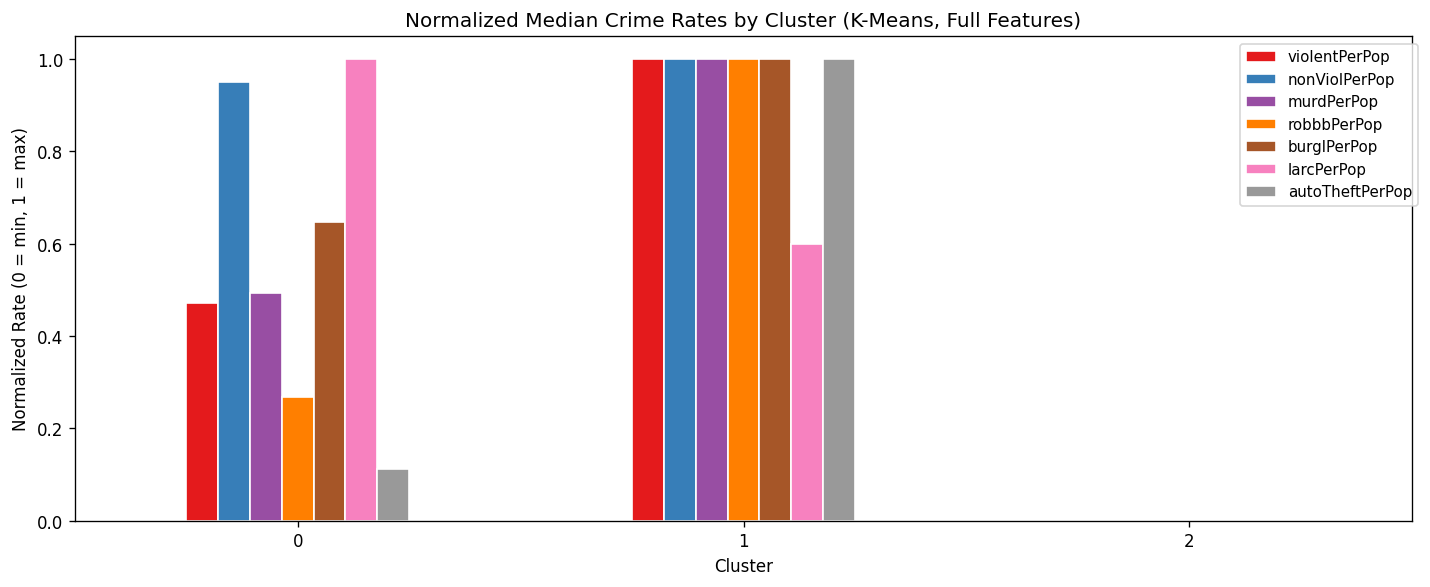

In [18]:
crime_cols = ['violentPerPop', 'nonViolPerPop', 'murdPerPop', 'robbbPerPop',
              'burglPerPop', 'larcPerPop', 'autoTheftPerPop']
crime_avail = [c for c in crime_cols if c in targets.columns]

cluster_crime = targets_cl.groupby('cluster')[crime_avail].median()
print('Median crime rates per cluster:')
print(cluster_crime.round(2))

cluster_crime_norm = (cluster_crime - cluster_crime.min()) / (cluster_crime.max() - cluster_crime.min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 5))
cluster_crime_norm.plot(kind='bar', ax=ax, colormap='Set1', edgecolor='white')
ax.set_title('Normalized Median Crime Rates by Cluster (K-Means, Full Features)', fontsize=12)
ax.set_xlabel('Cluster'); ax.set_ylabel('Normalized Rate (0 = min, 1 = max)')
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/cluster_crime_profile.png', dpi=150, bbox_inches='tight')
plt.show()

Median economic indicators per cluster:
         medIncome  pctPoverty  pctUnemploy  pctCollGrad  pct2Par  pctBlack  \
cluster                                                                       
0       24509.0000     15.3000       6.7700      15.8600  69.0000    6.7100   
1       29206.0000     16.8200       8.5200      14.0600  70.6500    4.6200   
2       43309.0000      3.9800       3.9600      28.4200  83.1800    1.4100   

         pctWhite  popDensity  pctNotHSgrad  
cluster                                      
0         86.8400   1876.5000       26.4000  
1         62.0300   5434.6000       34.3200  
2         94.4500   1910.5000       13.4300  


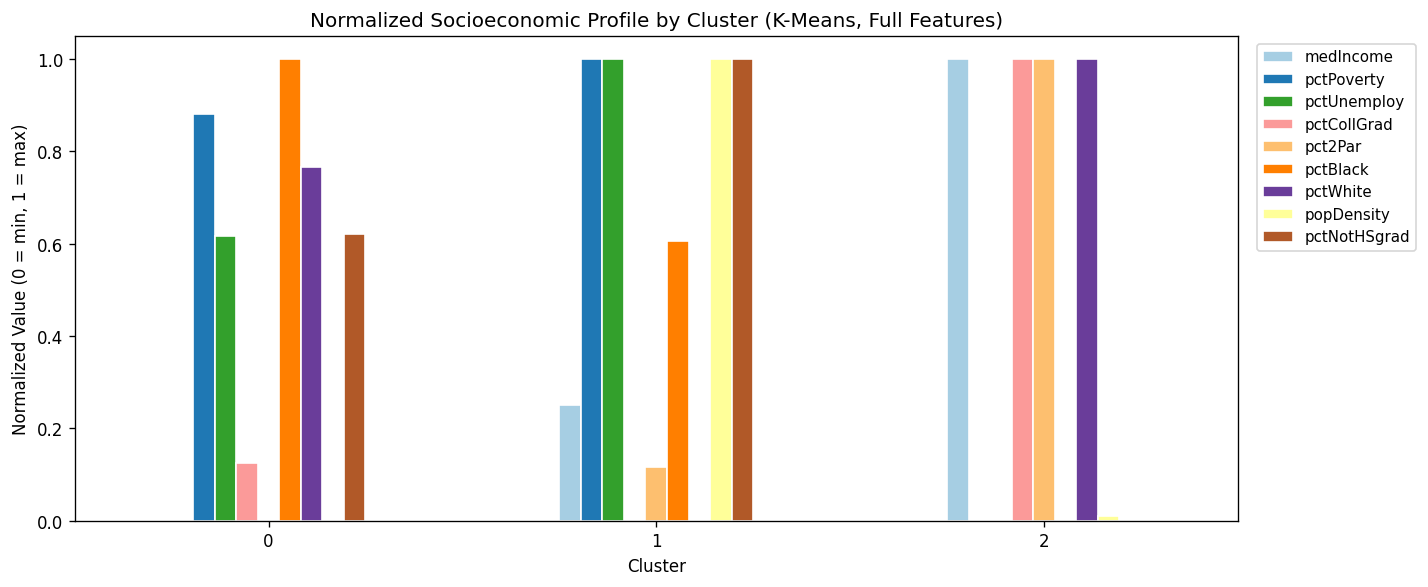

In [19]:
econ_cols = ['medIncome', 'pctPoverty', 'pctUnemploy', 'pctCollGrad',
             'pct2Par', 'pctBlack', 'pctWhite', 'popDensity', 'pctNotHSgrad']
econ_avail = [c for c in econ_cols if c in X_imputed.columns]

cluster_econ = X_interp.groupby('cluster')[econ_avail].median()
print('Median economic indicators per cluster:')
print(cluster_econ.round(2))

cluster_econ_norm = (cluster_econ - cluster_econ.min()) / (cluster_econ.max() - cluster_econ.min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 5))
cluster_econ_norm.plot(kind='bar', ax=ax, colormap='Paired', edgecolor='white')
ax.set_title('Normalized Socioeconomic Profile by Cluster (K-Means, Full Features)', fontsize=12)
ax.set_xlabel('Cluster'); ax.set_ylabel('Normalized Value (0 = min, 1 = max)')
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/cluster_econ_profile.png', dpi=150, bbox_inches='tight')
plt.show()

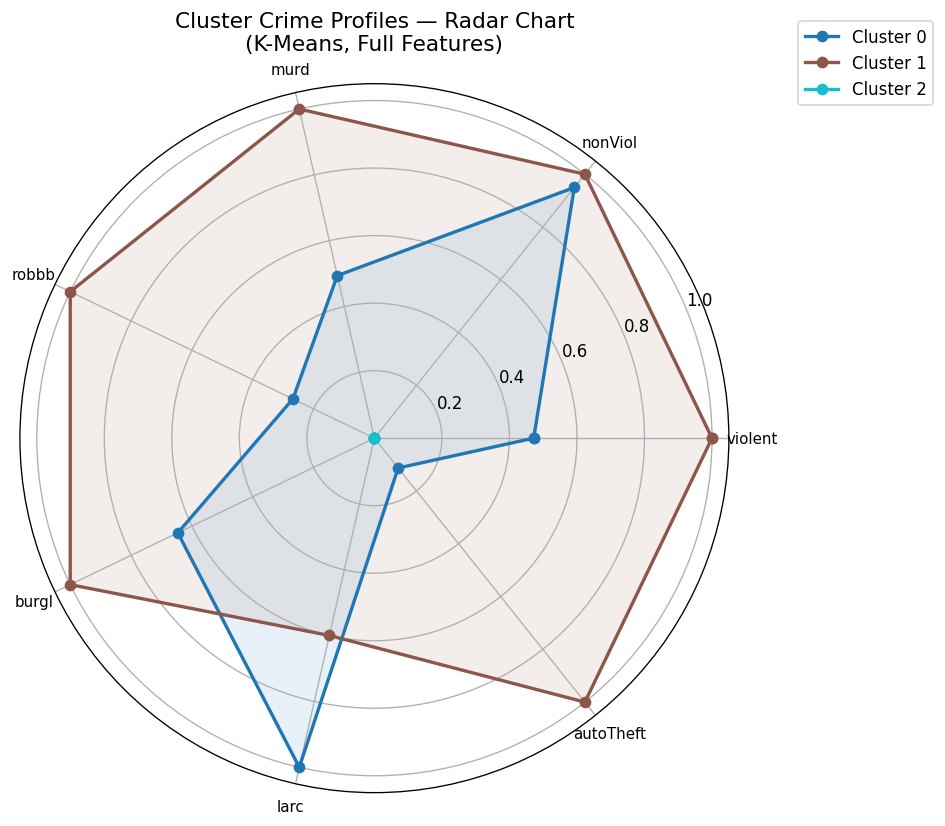

In [20]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.cm as cm

categories = [c.replace('PerPop', '').replace('Per', '\n') for c in crime_avail]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = cm.tab10(np.linspace(0, 1, len(cluster_crime_norm)))

for i, (cluster_id, row) in enumerate(cluster_crime_norm.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[i], label=f'Cluster {cluster_id}')
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=9)
ax.set_title('Cluster Crime Profiles — Radar Chart\n(K-Means, Full Features)', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('../figures/cluster_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Opis klastera

Na osnovu rezultata prikazanih iznad, svaki klaster možemo posmatrati kroz ključne socioekonomske i kriminalne indikatore:

In [21]:
summary = pd.concat([
    cluster_econ[['medIncome', 'pctPoverty', 'pctUnemploy', 'pctCollGrad', 'pct2Par']],
    cluster_crime[['violentPerPop', 'murdPerPop', 'burglPerPop']]
], axis=1)
summary.index.name = 'Cluster'
print('Cluster Summary Table:')
print(summary.round(2).to_string())

Cluster Summary Table:
         medIncome  pctPoverty  pctUnemploy  pctCollGrad  pct2Par  violentPerPop  murdPerPop  burglPerPop
Cluster                                                                                                  
0       24509.0000     15.3000       6.7700      15.8600  69.0000       549.2200      5.2400    1093.0400
1       29206.0000     16.8200       8.5200      14.0600  70.6500       950.5100     10.6100    1391.2400
2       43309.0000      3.9800       3.9600      28.4200  83.1800       190.8400      0.0000     548.1000


## 7. Krajnji zaključak

In [22]:
best_configs = results_df.dropna(subset=['Silhouette']).sort_values('Silhouette', ascending=False)

print('=== FINAL EVALUATION SUMMARY ===')
print(f'Total configurations evaluated: {len(results_df)}')
print(f'Algorithms: {results_df["Algorithm"].nunique()}')
print(f'Feature sets: {results_df["Feature Set"].nunique()}')
print()
print('Top 5 configurations by Silhouette Score:')
print(best_configs[['Algorithm', 'Feature Set', 'n_clusters', 'Silhouette', 'Davies-Bouldin']].head(5).to_string(index=False))
print()
print('Worst 5 configurations by Silhouette Score:')
print(best_configs[['Algorithm', 'Feature Set', 'n_clusters', 'Silhouette', 'Davies-Bouldin']].tail(5).to_string(index=False))

=== FINAL EVALUATION SUMMARY ===
Total configurations evaluated: 29
Algorithms: 8
Feature sets: 4

Top 5 configurations by Silhouette Score:
               Algorithm Feature Set  n_clusters  Silhouette  Davies-Bouldin
 Agglomerative (Average)      PCA-70           3      0.7693          0.2680
Agglomerative (Complete)      PCA-70           3      0.7693          0.2680
 Agglomerative (Average)      PCA-80           3      0.7504          0.2869
                    CURE      PCA-80           3      0.7504          0.2869
Agglomerative (Complete)      PCA-80           3      0.7504          0.2869

Worst 5 configurations by Silhouette Score:
           Algorithm Feature Set  n_clusters  Silhouette  Davies-Bouldin
             K-Means        Full           3      0.1777          1.7846
               BIRCH        Full           3      0.1604          1.8891
Agglomerative (Ward)        Full           3      0.1604          1.8891
               BIRCH    Economic           3      0.1559    